In [1]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_info: str

In [2]:
def start_play(state:State):
    print("Start play node has been called")
    return {"graph_info":state['graph_info'] + "I am playing to play"}

def cricket(state:State):
    print("Cricket node has been called")
    return {"graph_info":state['graph_info'] + "Cricket"}

def football(state:State):
    print("Football node has been called")
    return {"graph_info":state['graph_info'] + "Football"}


In [3]:
import random
from typing import Literal

def random_play(state:State)-> Literal['cricket', 'football']:
    if random.random() > 0.5 :
        return "cricket"
    else:
        return "foorball"

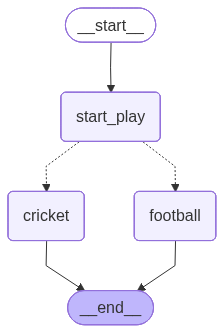

In [4]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

## Build Graph
graph = StateGraph(State)

## Add all the nodes
graph.add_node("start_play", start_play)
graph.add_node("cricket", cricket)
graph.add_node("football", football)

## Schedule the flow of the graph
graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", random_play)
graph.add_edge("cricket", END)
graph.add_edge("football", END)

## Complie the graph
compiled_graph = graph.compile()
display(Image(compiled_graph.get_graph().draw_mermaid_png()))


In [5]:
compiled_graph.invoke({"graph_info": "I'm Yash"})

Start play node has been called
Cricket node has been called


{'graph_info': "I'm YashI am playing to playCricket"}